# Imports e Configuração

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix


TECNICA_ATUAL = "Undersampling" 
PASTA_DADOS = os.path.join("..", "PreProcessing", TECNICA_ATUAL)

NOME_X_TRAIN = "X_train_under.csv"
NOME_Y_TRAIN = "y_train_under.csv"
NOME_X_TEST  = "X_test_scaled.csv"
NOME_Y_TEST  = "y_test.csv"

print(f"Treinamento REDE NEURAL (MLP) - Dados: {TECNICA_ATUAL}")

Treinamento REDE NEURAL (MLP) - Dados: Undersampling


# Carregamento

In [2]:
try:
    X_train = pd.read_csv(os.path.join(PASTA_DADOS, NOME_X_TRAIN))
    y_train = pd.read_csv(os.path.join(PASTA_DADOS, NOME_Y_TRAIN)).values.ravel()
    X_test = pd.read_csv(os.path.join(PASTA_DADOS, NOME_X_TEST))
    y_test = pd.read_csv(os.path.join(PASTA_DADOS, NOME_Y_TEST)).values.ravel()
    print("Dados carregados com sucesso!")
except Exception as e:
    print(f"Erro ao ler arquivos: {e}")

Dados carregados com sucesso!


# Treinamento e Arquitetura da Rede

In [3]:
rede_neural = MLPClassifier(
    hidden_layer_sizes=(100, 50), 
    activation='relu',            
    solver='adam',                
    alpha=0.0001,                 
    max_iter=1000,                
    early_stopping=True,          
    random_state=42
)

print("Treinando a Rede Neural (Isso pode demorar um pouco)...")
rede_neural.fit(X_train, y_train)

print("Treinamento Concluído!")

Treinando a Rede Neural (Isso pode demorar um pouco)...
Treinamento Concluído!


# Avaliação

--- Relatório de Classificação ---
              precision    recall  f1-score   support

Saudável (0)       0.77      0.86      0.82       138
 Benigno (1)       0.75      0.37      0.50       142
  Câncer (2)       0.07      0.38      0.12        13

    accuracy                           0.60       293
   macro avg       0.53      0.54      0.48       293
weighted avg       0.73      0.60      0.63       293



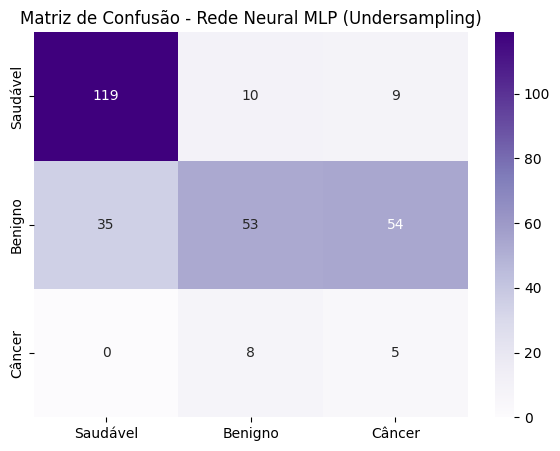

💾 Modelo salvo em: ..\PreProcessing\Undersampling\modelo_redeneural_undersampling.pkl


In [4]:
y_pred = rede_neural.predict(X_test)

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Saudável (0)', 'Benigno (1)', 'Câncer (2)']))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Saudável', 'Benigno', 'Câncer'], yticklabels=['Saudável', 'Benigno', 'Câncer'])
plt.title(f"Matriz de Confusão - Rede Neural MLP ({TECNICA_ATUAL})")
plt.show()

# Salvando
caminho_modelo = os.path.join(PASTA_DADOS, f'modelo_redeneural_{TECNICA_ATUAL.lower()}.pkl')
joblib.dump(rede_neural, caminho_modelo)
print(f"💾 Modelo salvo em: {caminho_modelo}")